In [28]:
import pandas as pd

file = 'Daily_PnL_Vectors.xlsx'
df = pd.read_excel(file)

df['AS_OF_DATE'] = pd.to_datetime(df['AS_OF_DATE'])
df = df.sort_values('AS_OF_DATE')

unique_dates = sorted(df['AS_OF_DATE'].unique())
selected_dates = unique_dates[::10]  # every 10th date

# Filter for selected dates
filtered_df = df[df['AS_OF_DATE'].isin(selected_dates)].copy()

# Optionally, limit to 500 PnL values per start date
filtered_df['row_number'] = filtered_df.groupby('AS_OF_DATE').cumcount()
filtered_df = filtered_df[filtered_df['row_number'] < 500]
filtered_df = filtered_df.drop(columns='row_number')

# Export
filtered_df.to_excel('PnLStrips_Every10thDate_longformat.xlsx', index=False)


In [30]:
import pandas as pd

file = 'Daily_PnL_Vectors.xlsx'
df = pd.read_excel(file)
df['AS_OF_DATE'] = pd.to_datetime(df['AS_OF_DATE'])
df = df.sort_values('AS_OF_DATE')

# Pivot to get ITEM_NAME as columns, AS_OF_DATE as rows
pivot_df = df.pivot_table(
    index='AS_OF_DATE',
    columns='ITEM_NAME',
    values='ITEM_VALUE',
    aggfunc='first'  # If there’s only one value per (date, name), 'first' is fine
)

# Optionally reset index for exporting to Excel with date in a column
pivot_df = pivot_df.reset_index()

# Export to Excel
pivot_df.to_excel('PnL_Pivot_By_Date_And_Item.xlsx', index=False)


In [36]:
import pandas as pd

file = 'Daily_PnL_Vectors.xlsx'
df = pd.read_excel(file)
df['AS_OF_DATE'] = pd.to_datetime(df['AS_OF_DATE'])
df = df.sort_values('AS_OF_DATE')

# Find sorted unique dates
unique_dates = sorted(df['AS_OF_DATE'].unique())

# Set your anchor date
start_date = pd.to_datetime('2024-12-31')
if start_date in unique_dates:
    start_idx = unique_dates.index(start_date)
else:
    raise ValueError("Start date 2024-12-31 not found in your data.")

# Select every 10th date starting from the anchor
selected_dates = unique_dates[start_idx::10]

# Filter the DataFrame for these dates
filtered_df = df[df['AS_OF_DATE'].isin(selected_dates)]

# Pivot as before
pivot_df = filtered_df.pivot_table(
    index='AS_OF_DATE',
    columns='ITEM_NAME',
    values='ITEM_VALUE',
    aggfunc='first'
).reset_index()

print(pivot_df)

# Export
pivot_df.to_excel('PnL_Pivot_By_Every10thDate.xlsx', index=False)


ITEM_NAME AS_OF_DATE  PNL_500D_10D99_HVAR_SCENARIO_1  \
0         2024-12-31                   -1.400813e+07   
1         2025-01-14                   -4.128263e+07   
2         2025-01-28                    5.085511e+07   
3         2025-02-11                   -1.476595e+07   
4         2025-02-25                    4.793816e+07   
5         2025-03-11                    2.562124e+07   
6         2025-03-25                   -9.793250e+06   
7         2025-04-08                    5.160700e+07   
8         2025-04-22                   -2.017325e+07   
9         2025-05-06                    1.402220e+07   
10        2025-05-20                   -3.958319e+07   
11        2025-06-02                    1.121087e+07   
12        2025-06-16                   -6.557345e+06   
13        2025-06-30                    5.638691e+07   
14        2025-07-14                   -3.932934e+07   
15        2025-07-28                   -1.243799e+05   
16        2025-08-11                    3.218038

PermissionError: [Errno 13] Permission denied: 'PnL_Pivot_By_Every10thDate.xlsx'

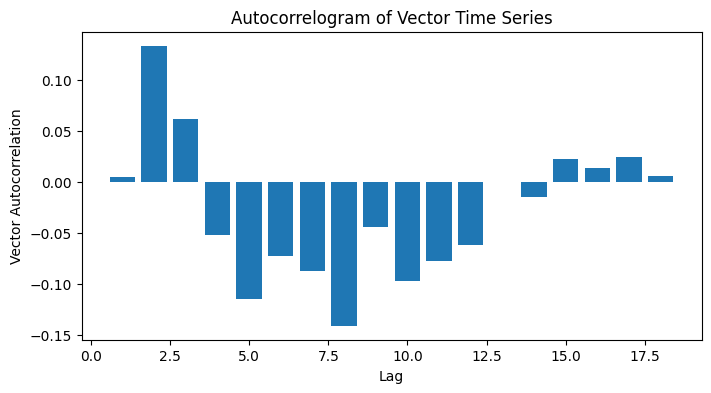

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

file_path = "PnL_Pivot_By_Every10thDate.xlsx"
df = pd.read_excel(file_path, sheet_name=0)

# Use the actual date column name
date_col = 'AS_OF_DATE'
df[date_col] = pd.to_datetime(df[date_col])

# Prepare matrix (exclude date column)
X = df.drop(columns=[date_col]).values
mean_vec = X.mean(axis=0)

def vector_autocorr(X, mean_vec, max_lag=17):
    autocorrs = []
    denom = np.sum([np.dot(x - mean_vec, x - mean_vec) for x in X])
    for lag in range(1, max_lag + 1):
        num = np.sum([np.dot(X[t] - mean_vec, X[t + lag] - mean_vec) for t in range(len(X) - lag)])
        autocorrs.append(num / denom)
    return autocorrs

lags = range(1, min(25, len(X) - 1) + 1)
autocorr = vector_autocorr(X, mean_vec, max_lag=max(lags))

plt.figure(figsize=(8,4))
plt.bar(lags, autocorr)
plt.xlabel("Lag")
plt.ylabel("Vector Autocorrelation")
plt.title("Autocorrelogram of Vector Time Series")
plt.show()


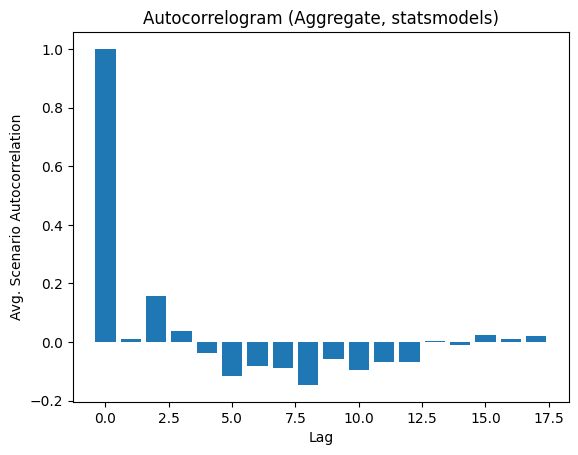

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf

file_path = "PnL_Pivot_By_Every10thDate.xlsx"
df = pd.read_excel(file_path, sheet_name=0)

# Use the correct date column
date_col = 'AS_OF_DATE'
df[date_col] = pd.to_datetime(df[date_col])

# Extract all scenarios as matrix
X = df.drop(columns=[date_col]).values

# Compute autocorrelation for each scenario (column) using statsmodels
max_lag = min(25, len(X) - 2)
acfs = []
for i in range(X.shape[1]):  # for each scenario
    # nan_policy converts nan to zero (optional depending on data quality)
    acfs.append(acf(X[:, i], nlags=max_lag, fft=True, missing='drop'))

# Aggregate across all scenario time series, e.g., average
acfs = np.array(acfs)
avg_acf = acfs.mean(axis=0)

lags = np.arange(max_lag + 1)
plt.bar(lags, avg_acf)
plt.xlabel("Lag")
plt.ylabel("Avg. Scenario Autocorrelation")
plt.title("Autocorrelogram (Aggregate, statsmodels)")
plt.show()


In [13]:
import pandas as pd

# Load the Excel file
df = pd.read_excel('Daily_PnL_Vectors.xlsx')

# More precise pattern: matches SCENARIO_1, SCENARIO_11, SCENARIO_101, etc.
# This ensures we're getting the scenario numbers that end with 1
filtered_df = df[df['ITEM_NAME'].str.contains(r'SCENARIO_(\d*1)$')]

print(f"Found {len(filtered_df)} records ending with '1'")
print(f"Unique dates found: {filtered_df['AS_OF_DATE'].nunique()}")
print(f"Unique scenarios found: {filtered_df['ITEM_NAME'].nunique()}")

# Display the results in a clean format
print("\nFiltered Results:")
print(filtered_df.to_string(index=False))

# Optional: Show summary by date
print("\n\nSummary by Date:")
summary = filtered_df.groupby('AS_OF_DATE').agg(
    Scenarios=('ITEM_NAME', 'count'),
    Avg_PnL=('ITEM_VALUE', 'mean'),
    Min_PnL=('ITEM_VALUE', 'min'),
    Max_PnL=('ITEM_VALUE', 'max')
).round(2)
print(summary)

# Save to new Excel file
filtered_df.to_excel('scenarios_ending_with_1.xlsx', index=False)
print("Results saved to 'scenarios_ending_with_1.xlsx'")

C:\Users\francois.schmitt\AppData\Local\Temp\ipykernel_9536\2140163215.py:8: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  filtered_df = df[df['ITEM_NAME'].str.contains(r'SCENARIO_(\d*1)$')]


Found 9200 records ending with '1'
Unique dates found: 184
Unique scenarios found: 50

Filtered Results:
                       ITEM_NAME AS_OF_DATE    ITEM_VALUE
  PNL_500D_10D99_HVAR_SCENARIO_1 2025-09-11  2.547860e+07
PNL_500D_10D99_HVAR_SCENARIO_101 2025-09-11  1.986794e+07
 PNL_500D_10D99_HVAR_SCENARIO_11 2025-09-11  2.239674e+07
PNL_500D_10D99_HVAR_SCENARIO_111 2025-09-11  2.496748e+07
PNL_500D_10D99_HVAR_SCENARIO_121 2025-09-11 -1.155899e+07
PNL_500D_10D99_HVAR_SCENARIO_131 2025-09-11  1.858505e+07
PNL_500D_10D99_HVAR_SCENARIO_141 2025-09-11  6.434441e+07
PNL_500D_10D99_HVAR_SCENARIO_151 2025-09-11 -2.007302e+07
PNL_500D_10D99_HVAR_SCENARIO_161 2025-09-11  1.464832e+07
PNL_500D_10D99_HVAR_SCENARIO_171 2025-09-11 -5.664212e+06
PNL_500D_10D99_HVAR_SCENARIO_181 2025-09-11  1.146044e+07
PNL_500D_10D99_HVAR_SCENARIO_191 2025-09-11 -5.867596e+07
PNL_500D_10D99_HVAR_SCENARIO_201 2025-09-11  4.449115e+07
 PNL_500D_10D99_HVAR_SCENARIO_21 2025-09-11  3.946283e+07
PNL_500D_10D99_HVAR_SCENA

In [14]:
import pandas as pd

# Load the Excel file
df = pd.read_excel('Daily_PnL_Vectors.xlsx')

# Filter rows where ITEM_NAME ends with '1'
filtered_df = df[df['ITEM_NAME'].str.contains(r'SCENARIO_(\d*1)$')]

print(f"Found {len(filtered_df)} records ending with '1'")
print(f"Unique dates found: {filtered_df['AS_OF_DATE'].nunique()}")
print(f"Unique scenarios found: {filtered_df['ITEM_NAME'].nunique()}")

# Pivot the table: AS_OF_DATE as rows, ITEM_NAME as columns, ITEM_VALUE as values
pivoted_df = filtered_df.pivot(
    index='AS_OF_DATE', 
    columns='ITEM_NAME', 
    values='ITEM_VALUE'
)

# Reset index to make AS_OF_DATE a regular column
pivoted_df.reset_index(inplace=True)

# Rename the index column if needed
pivoted_df.rename_axis(None, axis=1, inplace=True)

print("\nPivoted DataFrame shape:", pivoted_df.shape)
print("\nPivoted DataFrame preview:")
print(pivoted_df.head())

# Save the pivoted data to a new Excel file
pivoted_df.to_excel('scenarios_ending_with_1_pivoted.xlsx', index=False)
print("\nPivoted results saved to 'scenarios_ending_with_1_pivoted.xlsx'")

# Optional: Display the column names to verify the structure
print("\nColumn names in the pivoted file:")
print(pivoted_df.columns.tolist())

C:\Users\francois.schmitt\AppData\Local\Temp\ipykernel_9536\3987078010.py:7: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  filtered_df = df[df['ITEM_NAME'].str.contains(r'SCENARIO_(\d*1)$')]


Found 9200 records ending with '1'
Unique dates found: 184
Unique scenarios found: 50

Pivoted DataFrame shape: (184, 51)

Pivoted DataFrame preview:
  AS_OF_DATE  PNL_500D_10D99_HVAR_SCENARIO_1  \
0 2024-12-31                   -1.400813e+07   
1 2025-01-01                    1.217017e+07   
2 2025-01-02                    1.188546e+07   
3 2025-01-03                   -6.931968e+05   
4 2025-01-06                    6.867935e+06   

   PNL_500D_10D99_HVAR_SCENARIO_101  PNL_500D_10D99_HVAR_SCENARIO_11  \
0                      8.469081e+07                    -2.082750e+07   
1                      6.120413e+07                    -5.750891e+07   
2                      1.475837e+07                    -5.513352e+07   
3                     -3.204529e+07                    -5.928054e+07   
4                     -3.091208e+07                    -6.201275e+07   

   PNL_500D_10D99_HVAR_SCENARIO_111  PNL_500D_10D99_HVAR_SCENARIO_121  \
0                      8.299817e+06                    

In [17]:
import pandas as pd
import re

# Load the Excel file
df = pd.read_excel('Daily_PnL_Vectors.xlsx')

# Filter rows where ITEM_NAME ends with '1'
filtered_df = df[df['ITEM_NAME'].str.contains(r'SCENARIO_(\d*1)$')]

# Extract scenario number for sorting
def get_scenario_num(item_name):
    match = re.search(r'SCENARIO_(\d+)$', item_name)
    return int(match.group(1)) if match else 0

# Add a temporary column for sorting
filtered_df['scenario_num'] = filtered_df['ITEM_NAME'].apply(get_scenario_num)
filtered_df = filtered_df.sort_values('scenario_num')

# Pivot the table
pivoted_df = filtered_df.pivot(
    index='AS_OF_DATE', 
    columns='ITEM_NAME', 
    values='ITEM_VALUE'
)

# Reset index and clean up
pivoted_df.reset_index(inplace=True)
pivoted_df.rename_axis(None, axis=1, inplace=True)

# Get columns in numerical order (AS_OF_DATE first, then sorted scenario columns)
scenario_columns = sorted([col for col in pivoted_df.columns if col != 'AS_OF_DATE'], 
                         key=lambda x: get_scenario_num(x))
ordered_columns = ['AS_OF_DATE'] + scenario_columns
pivoted_df = pivoted_df[ordered_columns]

print("\nColumns in numerical order:")
print(ordered_columns)

# Save to Excel
pivoted_df.to_excel('scenarios_ending_with_1_pivoted.xlsx', index=False)
print("\nPivoted results saved to 'scenarios_ending_with_1_pivoted.xlsx'")

C:\Users\francois.schmitt\AppData\Local\Temp\ipykernel_9536\172275098.py:8: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  filtered_df = df[df['ITEM_NAME'].str.contains(r'SCENARIO_(\d*1)$')]
C:\Users\francois.schmitt\AppData\Local\Temp\ipykernel_9536\172275098.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['scenario_num'] = filtered_df['ITEM_NAME'].apply(get_scenario_num)



Columns in numerical order:
['AS_OF_DATE', 'PNL_500D_10D99_HVAR_SCENARIO_1', 'PNL_500D_10D99_HVAR_SCENARIO_11', 'PNL_500D_10D99_HVAR_SCENARIO_21', 'PNL_500D_10D99_HVAR_SCENARIO_31', 'PNL_500D_10D99_HVAR_SCENARIO_41', 'PNL_500D_10D99_HVAR_SCENARIO_51', 'PNL_500D_10D99_HVAR_SCENARIO_61', 'PNL_500D_10D99_HVAR_SCENARIO_71', 'PNL_500D_10D99_HVAR_SCENARIO_81', 'PNL_500D_10D99_HVAR_SCENARIO_91', 'PNL_500D_10D99_HVAR_SCENARIO_101', 'PNL_500D_10D99_HVAR_SCENARIO_111', 'PNL_500D_10D99_HVAR_SCENARIO_121', 'PNL_500D_10D99_HVAR_SCENARIO_131', 'PNL_500D_10D99_HVAR_SCENARIO_141', 'PNL_500D_10D99_HVAR_SCENARIO_151', 'PNL_500D_10D99_HVAR_SCENARIO_161', 'PNL_500D_10D99_HVAR_SCENARIO_171', 'PNL_500D_10D99_HVAR_SCENARIO_181', 'PNL_500D_10D99_HVAR_SCENARIO_191', 'PNL_500D_10D99_HVAR_SCENARIO_201', 'PNL_500D_10D99_HVAR_SCENARIO_211', 'PNL_500D_10D99_HVAR_SCENARIO_221', 'PNL_500D_10D99_HVAR_SCENARIO_231', 'PNL_500D_10D99_HVAR_SCENARIO_241', 'PNL_500D_10D99_HVAR_SCENARIO_251', 'PNL_500D_10D99_HVAR_SCENARIO_2

In [20]:
import pandas as pd
import re

# Load the Excel file
df = pd.read_excel('Daily_PnL_Vectors.xlsx')

print(f"Original data shape: {df.shape}")
print(f"Unique dates: {df['AS_OF_DATE'].nunique()}")
print(f"Unique scenarios: {df['ITEM_NAME'].nunique()}")

# Extract scenario number for sorting
def get_scenario_num(item_name):
    match = re.search(r'SCENARIO_(\d+)$', item_name)
    return int(match.group(1)) if match else 0

# Convert AS_OF_DATE to date-only format (remove time component)
df['AS_OF_DATE'] = pd.to_datetime(df['AS_OF_DATE']).dt.date

# Add a temporary column for sorting
df_sorted = df.copy()
df_sorted['scenario_num'] = df_sorted['ITEM_NAME'].apply(get_scenario_num)
df_sorted = df_sorted.sort_values(['AS_OF_DATE', 'scenario_num'])

# Pivot the entire table
pivoted_df = df_sorted.pivot(
    index='AS_OF_DATE', 
    columns='ITEM_NAME', 
    values='ITEM_VALUE'
)

# Reset index and clean up
pivoted_df.reset_index(inplace=True)
pivoted_df.rename_axis(None, axis=1, inplace=True)

# Get columns in numerical order (AS_OF_DATE first, then sorted scenario columns)
scenario_columns = sorted([col for col in pivoted_df.columns if col != 'AS_OF_DATE'], 
                         key=lambda x: get_scenario_num(x))
ordered_columns = ['AS_OF_DATE'] + scenario_columns
pivoted_df = pivoted_df[ordered_columns]

print(f"\nPivoted data shape: {pivoted_df.shape}")
print(f"Number of scenarios (columns): {len(scenario_columns)}")

# Verify we have all data
print(f"\nDate range: {pivoted_df['AS_OF_DATE'].min()} to {pivoted_df['AS_OF_DATE'].max()}")

# Save to Excel
output_filename = 'Daily_PnL_Vectors_Pivoted.xlsx'
pivoted_df.to_excel(output_filename, index=False)
print(f"\nComplete pivoted data saved to '{output_filename}'")

# Show the final dates without time
print("\nDates in final output:")
for date in pivoted_df['AS_OF_DATE']:
    print(f"  {date}")

# Optional: Show a preview of the column order
print("\nFirst 10 columns:")
for i, col in enumerate(ordered_columns[:10]):
    if col == 'AS_OF_DATE':
        print(f"0. {col}")
    else:
        num = get_scenario_num(col)
        print(f"{i}. {col} -> {num}")

Original data shape: (92000, 3)
Unique dates: 184
Unique scenarios: 500

Pivoted data shape: (184, 501)
Number of scenarios (columns): 500

Date range: 2024-12-31 to 2025-09-11

Complete pivoted data saved to 'Daily_PnL_Vectors_Pivoted.xlsx'

Dates in final output:
  2024-12-31
  2025-01-01
  2025-01-02
  2025-01-03
  2025-01-06
  2025-01-07
  2025-01-08
  2025-01-09
  2025-01-10
  2025-01-13
  2025-01-14
  2025-01-15
  2025-01-16
  2025-01-17
  2025-01-20
  2025-01-21
  2025-01-22
  2025-01-23
  2025-01-24
  2025-01-27
  2025-01-28
  2025-01-29
  2025-01-30
  2025-01-31
  2025-02-03
  2025-02-04
  2025-02-05
  2025-02-06
  2025-02-07
  2025-02-10
  2025-02-11
  2025-02-12
  2025-02-13
  2025-02-14
  2025-02-17
  2025-02-18
  2025-02-19
  2025-02-20
  2025-02-21
  2025-02-24
  2025-02-25
  2025-02-26
  2025-02-27
  2025-02-28
  2025-03-03
  2025-03-04
  2025-03-05
  2025-03-06
  2025-03-07
  2025-03-10
  2025-03-11
  2025-03-12
  2025-03-13
  2025-03-14
  2025-03-17
  2025-03-18
  2025

<Figure size 800x400 with 0 Axes>

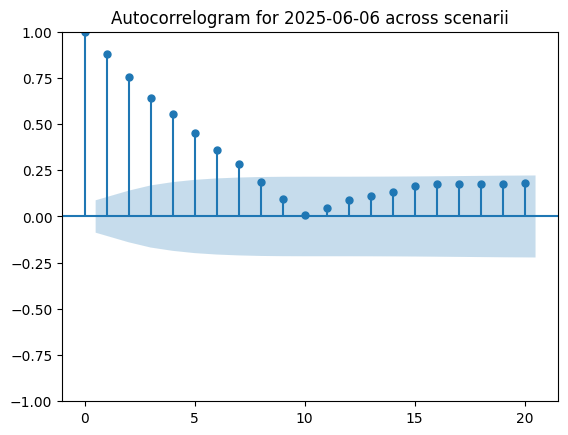

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

# Load data from Excel
file_path = 'Daily_PnL_Vectors_Pivoted.xlsx'
df = pd.read_excel(file_path, index_col=0, parse_dates=True)

# Ask user for a date input
date_str = input("Enter a date (YYYY-MM-DD): ").strip()
selected_date = pd.to_datetime(date_str)

# Check if the date is in the DataFrame index
if selected_date not in df.index:
    print(f"Date {selected_date.date()} not found in data.")
else:
    series = df.loc[selected_date]
    plt.figure(figsize=(8, 4))
    plot_acf(series, lags=min(20, len(series)//1.1), title=f'Autocorrelogram for {selected_date.date()} across scenarii')
    plt.show()
